**Table of contents**<a id='toc0_'></a>    
- [Part One: Load, inspect, and subset the dataset into features relevant to the research question.](#toc1_1_1_)    
      - [Load and inspect the initial dataset's distribution and columns:](#toc1_1_1_1_)    
      - [Subset the dataset to columns of interest before data cleaning](#toc1_1_1_2_)    
- [Part Two: Data Cleaning and Exploratory Data Analysis](#toc1_1_2_)    
      - [Inspect the distribution of the subsetted dataset](#toc1_1_2_1_)    
      - [Look for outliers in the numeric variables in the dataset](#toc1_1_2_2_)    
      - [Make changes to the dataset based on invalid values in the distribution](#toc1_1_2_3_)    
      - [Heatmap of the numeric features to look for multicollinearity](#toc1_1_2_4_)    
- [Part Four: Preprocessing and Feature Engineering (encoding, standardization, normalization, and adjusting features)](#toc1_1_3_)    
- [Part Five: Modeling](#toc1_1_4_)    
      - [Model 1: Linear Regression](#toc1_1_4_1_)    
      - [Model 2: Ridge Regression](#toc1_1_4_2_)    
      - [Model 3: Lasso Regression](#toc1_1_4_3_)    
- [Part 6: Feature Evaluation](#toc1_1_5_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [1]:
# Import packages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso, LassoCV
from sklearn.linear_model import Ridge, RidgeCV
import numpy as np
from sklearn.metrics import mean_squared_error
import math

### <a id='toc1_1_1_'></a>[Part One: Load, inspect, and subset the dataset into features relevant to the research question.](#toc0_)

#### <a id='toc1_1_1_1_'></a>[Load and inspect the initial dataset's distribution and columns:](#toc0_)

In [2]:
df = pd.read_csv(r"C:\Users\Ibrou\OneDrive\Freshman UNCC\2301\2302\housing_train.csv") # Import the dataset

In [3]:
# Look at the first rows of the data
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
# Size of the dataset
df.shape

(1460, 81)

In [5]:
# Distribution of numerical columns of the dataset
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [6]:
# List all column names in the dataset
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [7]:
# Look for duplicates within the entire dataset
df.duplicated().sum()

np.int64(0)

#### <a id='toc1_1_1_2_'></a>[Subset the dataset to columns of interest before data cleaning](#toc0_)

In [8]:
# Columns pertaining to physical attributes of the houses and the target variable, SalePrice
cols = [
    "LotArea", "OverallQual", "OverallCond", "YearBuilt", "YearRemodAdd", "CentralAir",
    "FullBath", "HalfBath", "BedroomAbvGr", "KitchenAbvGr",
    "GarageCars", "KitchenQual", "Fireplaces", "SalePrice"
]

df2 = df[cols]

### <a id='toc1_1_2_'></a>[Part Two: Data Cleaning and Exploratory Data Analysis](#toc0_)

#### <a id='toc1_1_2_1_'></a>[Inspect the distribution of the subsetted dataset](#toc0_)

In [9]:
# Look at the first rows of the subsetted dataset
df2.head()

,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,CentralAir,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,GarageCars,KitchenQual,Fireplaces,SalePrice
0,8450,7,5,2003,2003,Y,2,1,3,1,2,Gd,0,208500
1,9600,6,8,1976,1976,Y,2,0,3,1,2,TA,1,181500
2,11250,7,5,2001,2002,Y,2,1,3,1,2,Gd,1,223500
3,9550,7,5,1915,1970,Y,1,0,3,1,3,Gd,1,140000
4,14260,8,5,2000,2000,Y,2,1,4,1,3,Gd,1,250000


In [10]:
# Distribution of numerical columns of the new dataset
# Note: "YearBuilt" and "YearRemodAdd" are included as numeric but are interval variables where the others are ratio variables
# Note: "FullBath", "HalfBath", and "KitchenAbvGr" have some invalid values of 0, which we will remove later on
df2.describe()

,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,GarageCars,Fireplaces,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,10516.828082,6.099315,5.575342,1971.267808,1984.865753,1.565068,0.382877,2.866438,1.046575,1.767123,0.613014,180921.195890
std,9981.264932,1.382997,1.112799,30.202904,20.645407,0.550916,0.502885,0.815778,0.220338,0.747315,0.644666,79442.502883
min,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,34900.000000
25%,7553.500000,5.000000,5.000000,1954.000000,1967.000000,1.000000,0.000000,2.000000,1.000000,1.000000,0.000000,129975.000000
50%,9478.500000,6.000000,5.000000,1973.000000,1994.000000,2.000000,0.000000,3.000000,1.000000,2.000000,1.000000,163000.000000
75%,11601.500000,7.000000,6.000000,2000.000000,2004.000000,2.000000,1.000000,3.000000,1.000000,2.000000,1.000000,214000.000000
max,215245.000000,10.000000,9.000000,2010.000000,2010.000000,3.000000,2.000000,8.000000,3.000000,4.000000,3.000000,755000.000000


In [11]:
# Check for missing values for columns of interest
df2.isna().sum()

LotArea         0
OverallQual     0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
CentralAir      0
FullBath        0
HalfBath        0
BedroomAbvGr    0
KitchenAbvGr    0
GarageCars      0
KitchenQual     0
Fireplaces      0
SalePrice       0
dtype: int64

In [12]:
# Select numeric columns for visualizations
df2_numerical = df2.select_dtypes(include=[int, float]) # select numeric columns

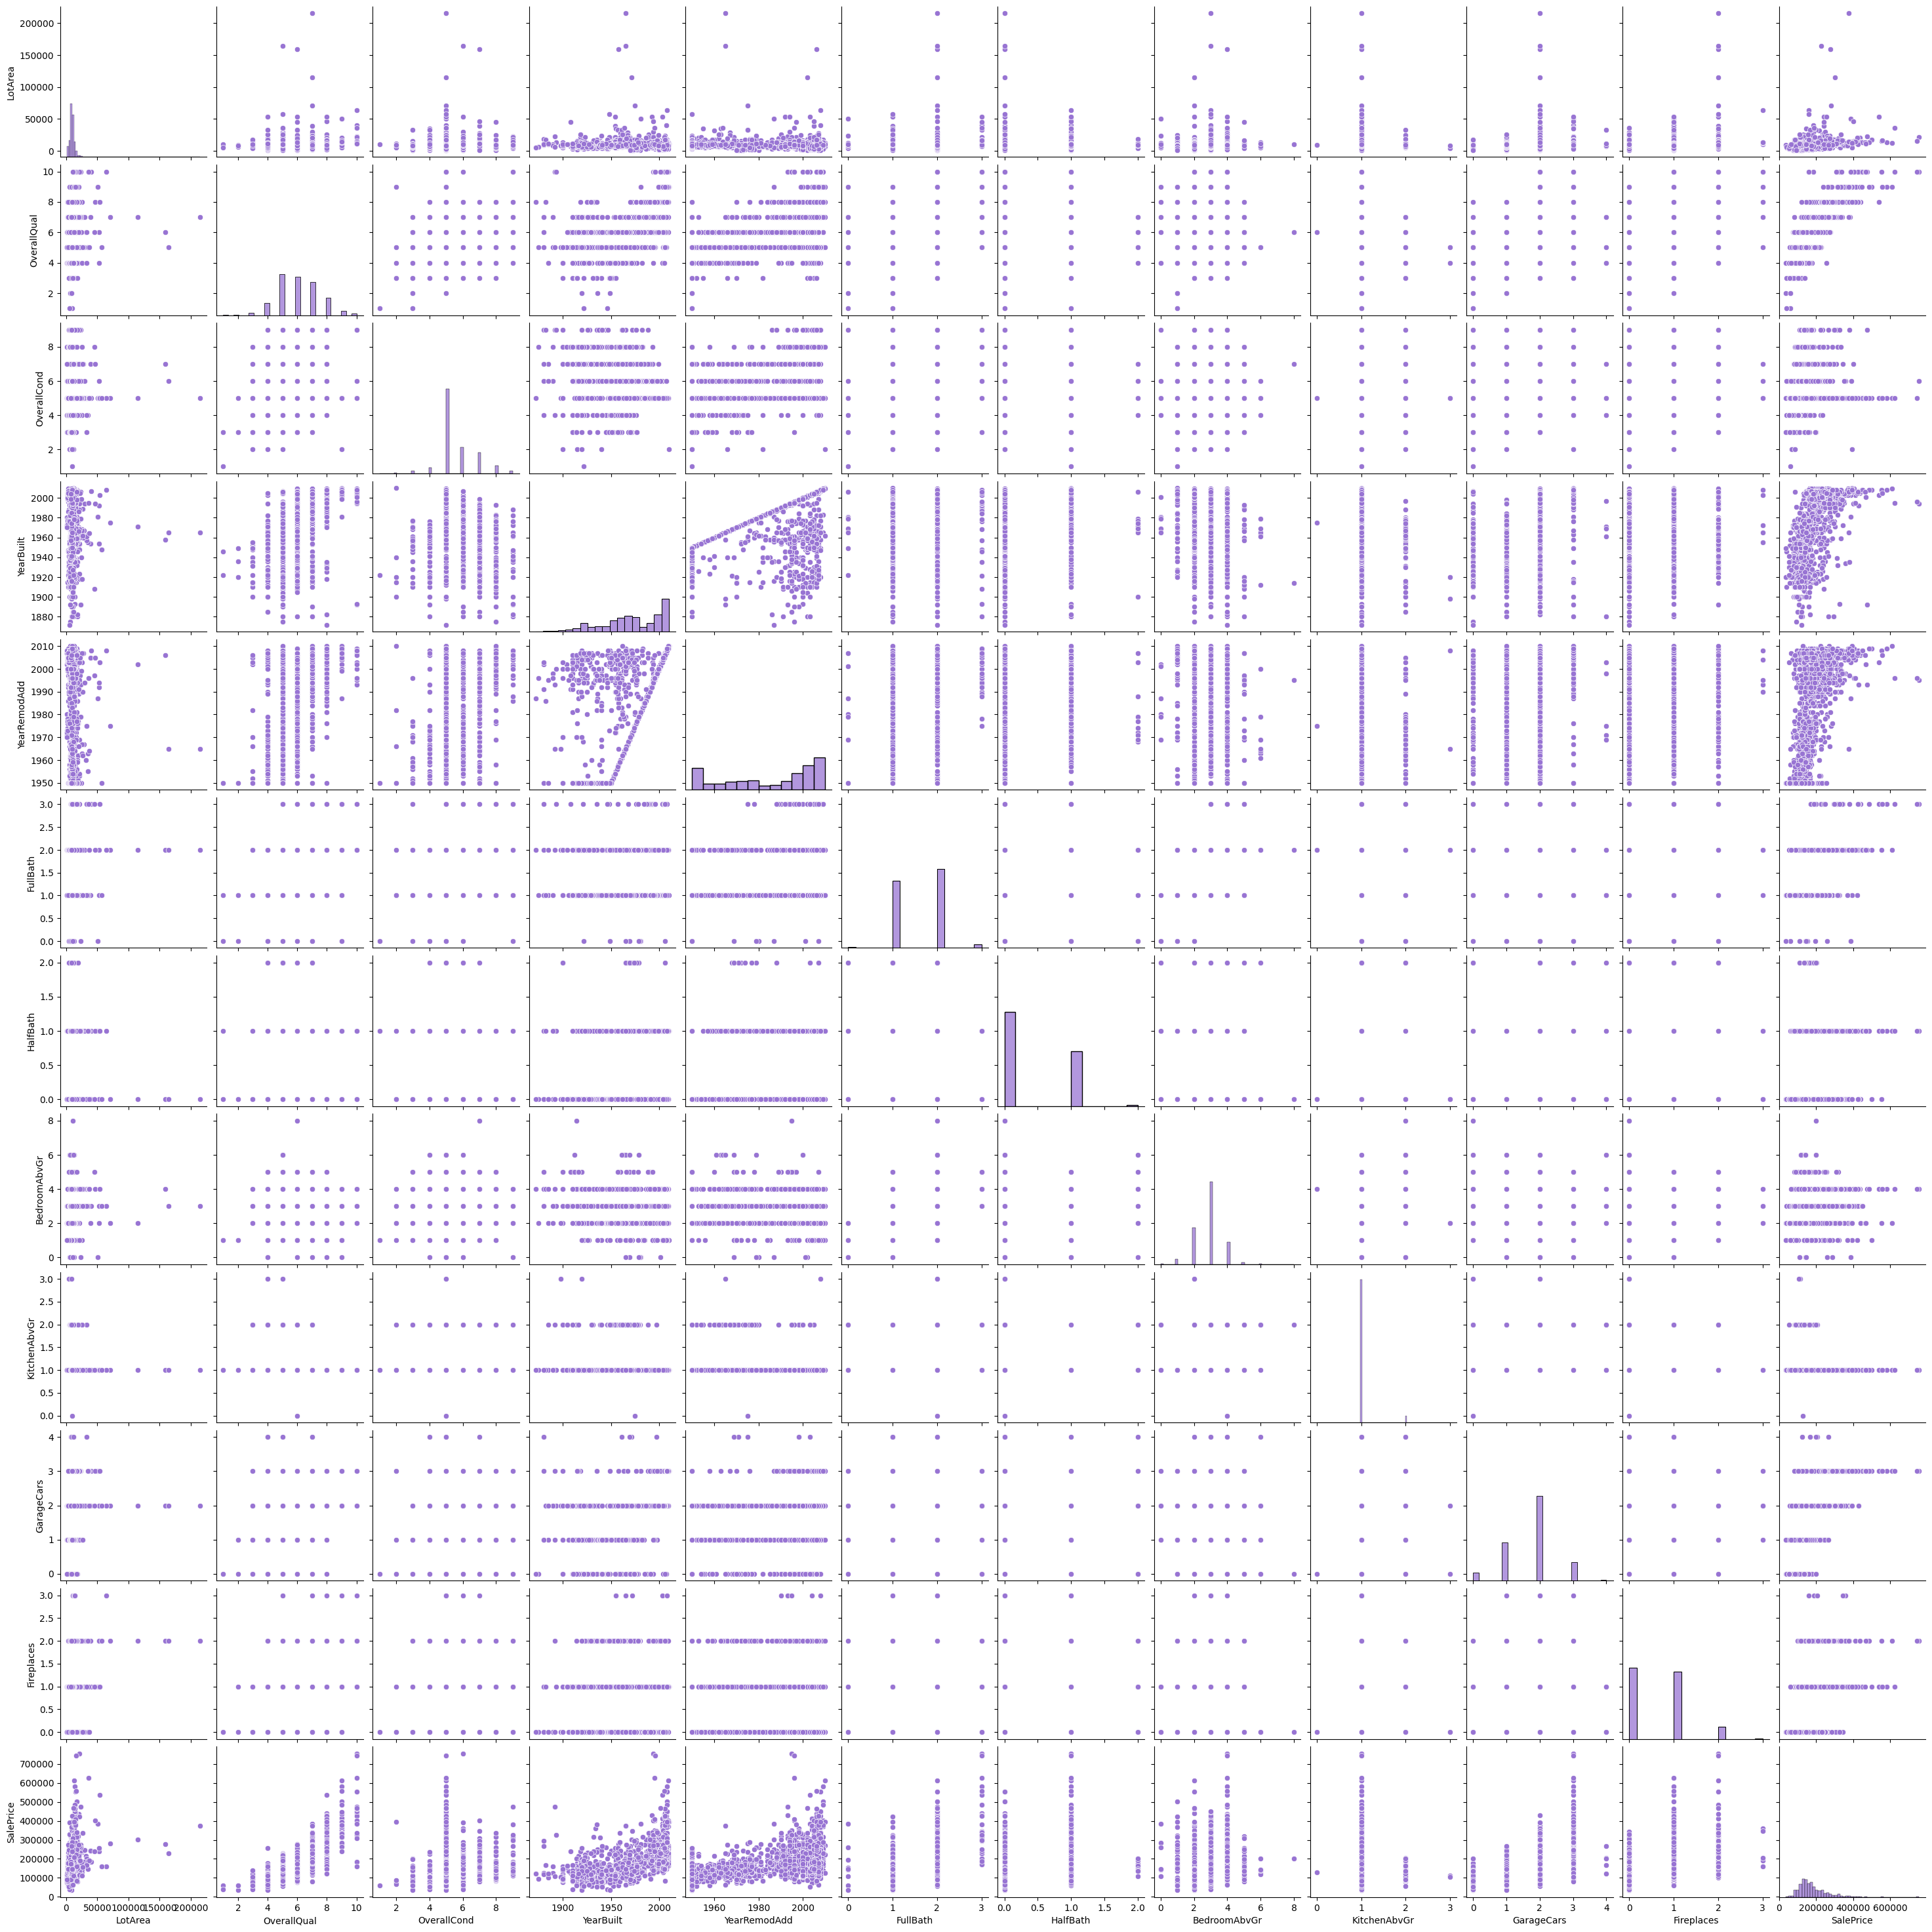

In [13]:
# Distribution of the numeric variables (scatterplots and histograms) shown in a pairplot
# Note: SalePrice is right-skewed, which is why we will log transform it later on to reduce skewness and make it more normal for modeling
sns.pairplot(df2_numerical, plot_kws={'color': '#9874D3'}, diag_kws={'color': '#9874D3'})

<Axes: xlabel='SalePrice', ylabel='Count'>

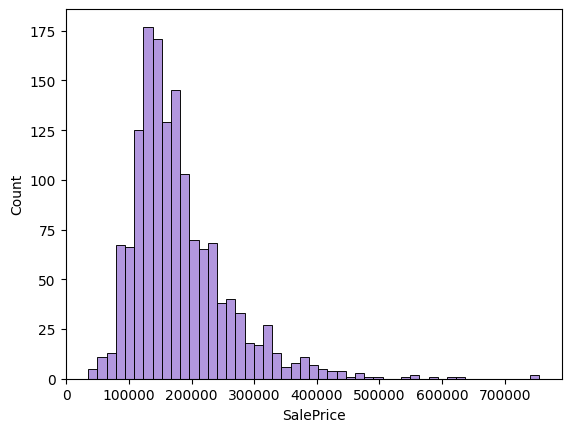

In [14]:
# Look closer at the distribution of the target, SalePrice
sns.histplot(df2_numerical['SalePrice'], color='#9874D3')

In [15]:
# Look at the unique values of the categorical columns
categorical_cols = df2.select_dtypes(include=["object"]).columns
# Iterate through the categorical columns and print their unique values
for c in categorical_cols:
    print(c, ":", df[c].unique())

CentralAir : <StringArray>
['Y', 'N']
Length: 2, dtype: str
KitchenQual : <StringArray>
['Gd', 'TA', 'Ex', 'Fa']
Length: 4, dtype: str


C:\Users\Ibrou\AppData\Local\Temp\ipykernel_20852\2836252414.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df2.select_dtypes(include=["object"]).columns


In [16]:
custom_palette = sns.color_palette("blend:#bca0dc,#3c1361", 25) # Create custom purple color palette

Boxplots of the categorical variables against the target, "SalePrice"

C:\Users\Ibrou\AppData\Local\Temp\ipykernel_20852\40322493.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="CentralAir", y="SalePrice", data=df2, palette=custom_palette) # Plot CentralAir against SalePrice
C:\Users\Ibrou\AppData\Local\Temp\ipykernel_20852\40322493.py:1: UserWarning: The palette list has more values (25) than needed (2), which may not be intended.
  sns.boxplot(x="CentralAir", y="SalePrice", data=df2, palette=custom_palette) # Plot CentralAir against SalePrice


<Axes: xlabel='CentralAir', ylabel='SalePrice'>

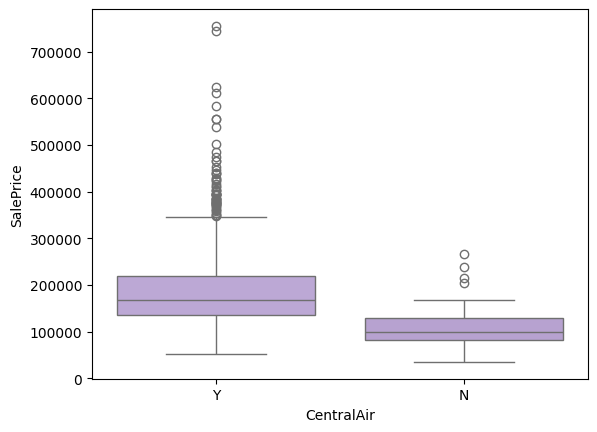

In [17]:
sns.boxplot(x="CentralAir", y="SalePrice", data=df2, palette=custom_palette) # Plot CentralAir against SalePrice 

C:\Users\Ibrou\AppData\Local\Temp\ipykernel_20852\3402674008.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="KitchenQual", y="SalePrice", data=df2, palette=custom_palette) # Plot KitchenQual against SalePrice
C:\Users\Ibrou\AppData\Local\Temp\ipykernel_20852\3402674008.py:1: UserWarning: The palette list has more values (25) than needed (4), which may not be intended.
  sns.boxplot(x="KitchenQual", y="SalePrice", data=df2, palette=custom_palette) # Plot KitchenQual against SalePrice


<Axes: xlabel='KitchenQual', ylabel='SalePrice'>

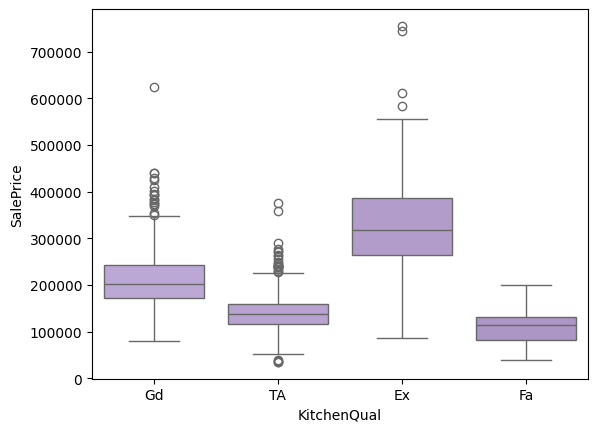

In [18]:
sns.boxplot(x="KitchenQual", y="SalePrice", data=df2, palette=custom_palette) # Plot KitchenQual against SalePrice

#### <a id='toc1_1_2_2_'></a>[Look for outliers in the numeric variables in the dataset](#toc0_)

In [19]:
# Define function to find and print outliers and the number of outliers in a column
def outliers(col_name, data):
    q1 = data[col_name].quantile(0.25) # Calculate the first quartile
    q3 = data[col_name].quantile(0.75) # Calculate the third quartile
    iqr = q3 - q1 # Calculate the IQR
    lower_bound = q1 - (1.5*iqr) # Find the lower bound for outliers
    upper_bound = q3 + (1.5*iqr) # Find the upper bound for outliers

    outliers = np.where((data[col_name] < lower_bound) | (data[col_name] > upper_bound)) # Identify outliers
    count = 0
    for i in outliers[0]: # Calculate the total number of outliers
        count += 1
    print("Number of outliers in", col_name, ": ", count) # Display the total number of outliers and what they are
    print("Outliers: ", data[col_name].iloc[outliers[0]])

In [20]:
# Call function for all numeric columns by iterating through them
for c in df2.select_dtypes(include=["int64", "float64"]).columns:
        outliers(c, df2)

Number of outliers in LotArea :  69
Outliers:  53      50271
66      19900
113     21000
120     21453
159     19378
        ...  
1396    57200
1409    20544
1423    19690
1430    21930
1446    26142
Name: LotArea, Length: 69, dtype: int64
Number of outliers in OverallQual :  2
Outliers:  375    1
533    1
Name: OverallQual, dtype: int64
Number of outliers in OverallCond :  125
Outliers:  1       8
15      8
24      8
88      2
91      3
       ..
1385    8
1397    8
1411    8
1435    9
1457    9
Name: OverallCond, Length: 125, dtype: int64
Number of outliers in YearBuilt :  7
Outliers:  304     1880
630     1880
747     1880
991     1882
1132    1880
1137    1875
1349    1872
Name: YearBuilt, dtype: int64
Number of outliers in YearRemodAdd :  0
Outliers:  Series([], Name: YearRemodAdd, dtype: int64)
Number of outliers in FullBath :  0
Outliers:  Series([], Name: FullBath, dtype: int64)
Number of outliers in HalfBath :  0
Outliers:  Series([], Name: HalfBath, dtype: int64)
Number of o

#### <a id='toc1_1_2_3_'></a>[Make changes to the dataset based on invalid values in the distribution](#toc0_)

In [21]:
# Remove rows with invalid values for "BedroomAbvGr", "KitchenAbvGr", and "FullBath" (0) as defined by the real world regulations
df2 = df2[df2["BedroomAbvGr"]>0]
df2 = df2[df2["KitchenAbvGr"]>0]
df2 = df2[df2["FullBath"]>0]

#### <a id='toc1_1_2_4_'></a>[Heatmap of the numeric features to look for multicollinearity](#toc0_)

<Axes: >

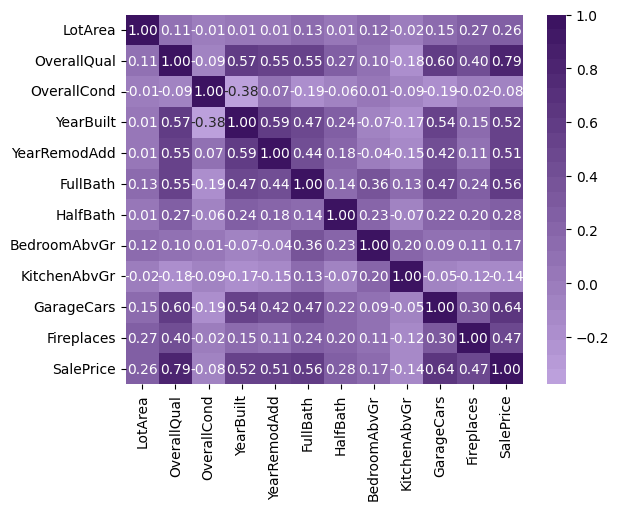

In [22]:
# Heatmap of the numeric variables (correlation matrix) showing their correlation coefficients
# Note: there is high correlation between some of the features, like "GarageCars" with "Overallqual" and "YearBuilt"
sns.heatmap(df2_numerical.corr(), cmap= custom_palette, annot=True, fmt=".2f") # Display the correlation coefficients to two decimal places

### <a id='toc1_1_3_'></a>[Part Four: Preprocessing and Feature Engineering (encoding, standardization, normalization, and adjusting features)](#toc0_)

Encode the values of the "Central Air" column

In [23]:
# Encode the categorical variable CentralAir as 1 for "Y" and 0 for "N" by replacing them in the dataframe
df2["CentralAir"] = df2["CentralAir"].replace({"Y": 1})
df2["CentralAir"] = df2["CentralAir"].replace({"N": 0})

In [24]:
df2.head() # Double check the encoding of CentralAir

,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,CentralAir,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,GarageCars,KitchenQual,Fireplaces,SalePrice
0,8450,7,5,2003,2003,1,2,1,3,1,2,Gd,0,208500
1,9600,6,8,1976,1976,1,2,0,3,1,2,TA,1,181500
2,11250,7,5,2001,2002,1,2,1,3,1,2,Gd,1,223500
3,9550,7,5,1915,1970,1,1,0,3,1,3,Gd,1,140000
4,14260,8,5,2000,2000,1,2,1,4,1,3,Gd,1,250000


Change the columns "YearBuilt" and "YearRemodAdd" to "Age" and "RemodAge" so that they can be treated as ratio numeric variables.

In [25]:
# Assign "Age" as the age at the time of sale
# Assign "RemodAge" as the number of years since remodeling at the time of sale
df2["Age"] = df["YrSold"]-df2["YearBuilt"] # Subtract the year built or remodelled from the year sold (in the original dataframe) to get the ages
df2["RemodAge"] = df["YrSold"]-df2["YearRemodAdd"]
df2.drop(columns=["YearBuilt", "YearRemodAdd"], inplace=True)

In [26]:
# Inspect the new columns
df2[["Age", "RemodAge"]].head()

,Age,RemodAge
0,5.0,5.0
1,31.0,31.0
2,7.0,6.0
3,91.0,36.0
4,8.0,8.0


Encode the remaining categorical columns

In [27]:
# Encode any remaining columns of type "object" using one-hot encoding
df2 = pd.get_dummies(df2, columns=["KitchenQual"], drop_first = True)

Split the data into x and y, training and testing sets

In [28]:
# Split the data into x and y
X = df2.drop(columns="SalePrice")
y = df2[["SalePrice"]]

In [29]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

Standardize/normalize the training and testing sets- separately to avoid data leakage
- Standardize the numeric features
- Use Log transformation on the traget to reduce skewness

In [30]:
scaler = StandardScaler() # Initialize the scaler
# Select the numeric columns for scaling
numerical = X.select_dtypes(include=[int, float]).columns

In [31]:
# Standardize the numeric columns in the training and testing X sets separately to avoid data leakage
X_train[numerical] = scaler.fit_transform(X_train[numerical])
X_test[numerical] = scaler.transform(X_test[numerical])

In [32]:
# Normalize the target variable using log transformation to reduce skewness (seen in EDA)
y_train["LNSalePrice"] = np.log(y_train["SalePrice"]) # Use log transformation on the training and testing sets separately to avoid data leakage
y_test["LNSalePrice"] = np.log(y_test["SalePrice"])
# Drop the orginal column to rename it
y_train.drop(columns="SalePrice", inplace = True)
y_test.drop(columns="SalePrice", inplace = True)

### <a id='toc1_1_4_'></a>[Part Five: Modeling](#toc0_)

#### <a id='toc1_1_4_1_'></a>[Model 1: Linear Regression](#toc0_)

Create and train the model

In [54]:
model1 = LinearRegression() # Initialize the model

In [55]:
model1 = model1.fit(X_train, y_train) # Fit the model to the training data

In [56]:
predictions1 = model1.predict(X_test) # Make predictions on the testing data

Evaluate the results and performance

In [57]:
intercept = model1.intercept_[0]
print(intercept) # Display the intercept of the linear regression model

12.094023089456918


In [58]:
r_sq1 = model1.score(X_test, y_test)
print(r_sq1) # R-squared value for the model on the testing data 

0.8258255969721122


In [59]:
mse1 = mean_squared_error(y_test, predictions1) # Find the mean square error
rmse1 = math.exp(np.sqrt(mse1)) # Find the RMSE by square rooting the MSE, exponentiate it to reverse the log transformation and interpret the value
print(rmse1) # Root mean squared error for the model on the testing data

1.180276604732235


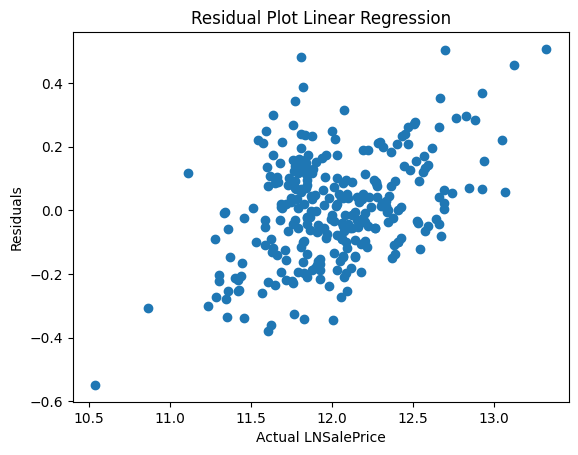

In [60]:
# Plot the residuals to determine if they are random
residuals = y_test["LNSalePrice"] - predictions1.flatten() # Find the residuals by subtracting the predicted values from the actual values of the target variable

plt.scatter(y_test["LNSalePrice"], residuals) # Create a scatterplot of the residuals against the actual values of the target variable
plt.xlabel("Actual LNSalePrice") # Title the plot and axis
plt.ylabel("Residuals")
plt.title("Residual Plot Linear Regression")
plt.show() # Display the plot

#### <a id='toc1_1_4_2_'></a>[Model 2: Ridge Regression](#toc0_)

Create and train the model

In [61]:
# Use RidgeCV to find the optimal alpha value for the regression model
alphas = np.logspace(-3, 3) # Define a range of alpha values to test
ridge_cv = RidgeCV(alphas=alphas) 
ridge_cv.fit(X_train, y_train)

optimal_alpha = ridge_cv.alpha_ # Get optimal alpha value
print(f"Optimal alpha value: {optimal_alpha}") # Print optimal alpha value

Optimal alpha value: 0.868511373751352


In [62]:
model2 = Ridge(alpha=optimal_alpha) # Initialize the model with the optimal alpha value
model2 = model2.fit(X_train, y_train) # Fit the model to the training data

Evaluate the results and performance

In [63]:
r_sq2 = model2.score(X_test, y_test)
print(r_sq2) # R-squared value for the model on the testing data 

0.8254908513674966


In [64]:
mse2 = mean_squared_error(y_test, (model2.predict(X_test))) # Find the mean square error
rmse2 = math.exp(np.sqrt(mse2)) # Find the RMSE by square rooting the MSE, exponentiate it to reverse the log transformation and interpret the value
print(rmse2) # Root mean squared error for the model on the testing data

1.180464519477012


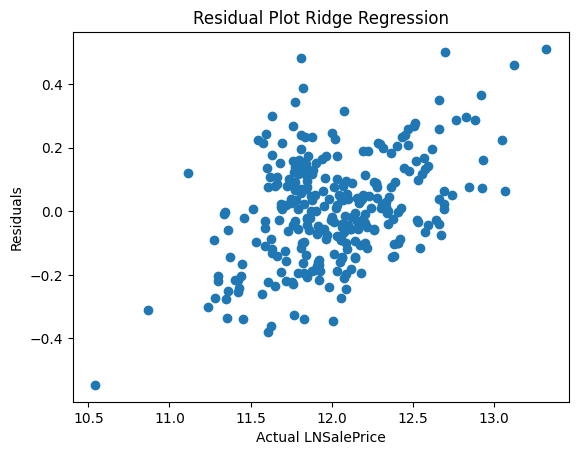

In [65]:
# Plot the residuals to determine if they are random
residuals = y_test["LNSalePrice"] - (model2.predict(X_test)).flatten() # Find the residuals by subtracting the predicted values from the actual values of the target variable

plt.scatter(y_test["LNSalePrice"], residuals) # Create a scatterplot of the residuals against the actual values of the target variable
plt.xlabel("Actual LNSalePrice") # Title the plot and axis
plt.ylabel("Residuals")
plt.title("Residual Plot Ridge Regression") 
plt.show() # Display the plot

#### <a id='toc1_1_4_3_'></a>[Model 3: Lasso Regression](#toc0_)

Create and train the model

In [66]:
# Use LassoCV to find the optimal alpha value for the regression

lasso_cv = LassoCV(alphas=alphas, max_iter=10000) # Initialize the model with the previous range of alpha values and set the max number of iterations to 10000
lasso_cv.fit(X_train, y_train) 
optimal_alpha = lasso_cv.alpha_ # Get optimal alpha value
print(f"Optimal alpha value: {optimal_alpha}") # Print optimal alpha value

Optimal alpha value: 0.001


c:\Users\Ibrou\OneDrive\Freshman UNCC\2301\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1756: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [67]:
model3 = Lasso(alpha=optimal_alpha) # Initialize the model with the optimal alpha value
model3 = model3.fit(X_train, y_train) # Fit the model to the training data

Evaluate the results and performance

In [68]:
r_sq3 = model3.score(X_test, y_test)
print(r_sq3) # R-squared value for the model on the testing data 

0.8219238802986037


In [69]:
mse3 = mean_squared_error(y_test, model3.predict(X_test)) # Find the mean square error
rmse3 = math.exp(np.sqrt(mse3)) # Find the RMSE by square rooting the MSE, exponentiate it to reverse the log transformation and interpret the value
print(rmse3) # Root mean squared error for the model on the testing data

1.1824576496638906


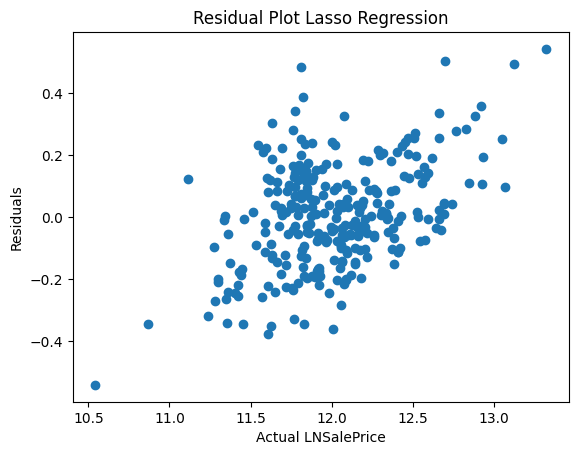

In [70]:
# Plot the residuals to determine if they are random
residuals = y_test["LNSalePrice"] - (model3.predict(X_test)).flatten() # Find the residuals by subtracting the predicted values from the actual values of the target variable

plt.scatter(y_test["LNSalePrice"], residuals) # Create a scatterplot of the residuals against the actual values of the target variable
plt.xlabel("Actual LNSalePrice") # Title the plot and axis
plt.ylabel("Residuals")
plt.title("Residual Plot Lasso Regression") 
plt.show() # Display the plot

### <a id='toc1_1_5_'></a>[Part 6: Feature Evaluation](#toc0_)

Evaluate the features that Model 1, which performed best, identified as most important.

In [71]:
import math
features = model1.coef_.flatten() # Find the coefficients of the linear regression model
for i in range(len(features)): # Iterate through the coefficients and exponentiate them to reverse the log transformation and interpret the values
    features[i-1] = math.exp(features[i-1])
feature_importance = pd.DataFrame(
    {
        "Feature": list(X_train.columns), # Name the features using the column names of the training data
        "Weight": features,
        "Absolute_Weight": abs(features),
    }
)

feature_importance = feature_importance.sort_values(by = "Absolute_Weight", ascending=False) # Sort the features by their absolute weight in descending order

Text(0.5, 1.0, 'Feature Importance')

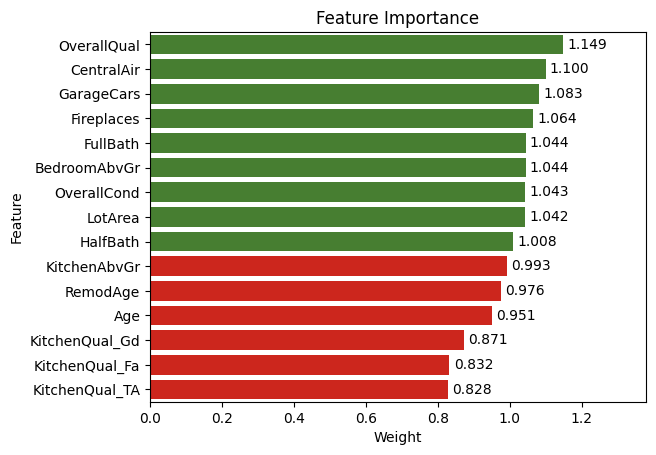

In [72]:
# Assign colors, red for negative impact (<1) and green for positive impact (>1)
color = ["#418b24" if x > 1 else "#E90c00" for x in feature_importance["Weight"]]

# create Bar Plot
ax = sns.barplot(
    data=feature_importance,
    x="Weight",
    y="Feature",
    palette=color,
    hue="Feature",
    legend=False,
)

# Show weights in bars
for container in ax.containers:
    ax.bar_label(container, padding=3, fmt="%.3f")

ax.margins(x=0.2)
plt.title("Feature Importance")